In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from morl_behavior_objective.analysis.metrics_clean import compute_zadu_metrics
from morl_behavior_objective.utils import get_pareto_front
from morl_behavior_objective.utils import load_transformer_embeddings
from morl_behavior_objective.utils import render_policy

# Set matplotlib parameters
mpl.rcParams["pdf.fonttype"] = 42  # use true-type
mpl.rcParams["ps.fonttype"] = 42  # use true-type
mpl.rcParams["font.size"] = 18
mpl.rcParams["lines.linewidth"] = 2.2
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath,amssymb,underscore}"
mpl.rcParams["text.usetex"] = True
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 16

colors = [
    "#5CB5FF",
    "#D55E00",
    "#009E73",
    "#e6194b",
]

/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-concave-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/ffelte/Doc

## Load all the data

### Load all environments

In [60]:
seed = 3

# Configuration for environments
environments = {
    "cheetah": {
        "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed0",
        "embedding_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_be_MHC_e100_seed{seed}.json",
    },
    "highway": {
        "trajectory_dir": "../../trajectories/morld/mo-highway-fast-v0/seed0",
        "embedding_path": f"../../trajectories/morld/mo-highway-fast-v0/embeddings/mean_be_MHW_e100_seed{seed}.json",
    },
    "hopper_2d": {
        "trajectory_dir": "../../trajectories/morld/mo-hopper-2obj-v5/seed0",
        "embedding_path": f"../../trajectories/morld/mo-hopper-2obj-v5/embeddings/mean_be_MHo2_e200_seed{seed}.json",
    },
    "hopper_3d": {
        "trajectory_dir": "../../trajectories/morld/mo-hopper-v5/seed0",
        "embedding_path": f"../../trajectories/morld/mo-hopper-v5/embeddings/mean_be_MHo_e200_seed{seed}.json",
    },
}

# Load returns (Pareto fronts)
returns_cheetah = get_pareto_front(environments["cheetah"]["trajectory_dir"])

returns_highway = get_pareto_front(environments["highway"]["trajectory_dir"])

# returns_hopper_2d = get_pareto_front(environments["hopper_2d"]["trajectory_dir"])

# returns_hopper_3d = get_pareto_front(environments["hopper_3d"]["trajectory_dir"])

# Load transformer embeddings
all_t_emb_cheetah, _ = load_transformer_embeddings(environments["cheetah"]["embedding_path"])
all_t_emb_high, _ = load_transformer_embeddings(environments["highway"]["embedding_path"])
# all_t_emb_hopper_2d, _ = load_transformer_embeddings(environments["hopper_2d"]["embedding_path"])
# all_t_emb_hopper_3d, _ = load_transformer_embeddings(environments["hopper_3d"]["embedding_path"])

print("Data loaded successfully:")
print(f" Cheetah: returns shape: {returns_cheetah.shape}, embeddings shape: {all_t_emb_cheetah.shape}")
print(f" Highway: returns shape: {returns_highway.shape}, embeddings shape: {all_t_emb_high.shape}")
# print(f" Hopper 2D: returns shape: {returns_hopper_2d.shape}, embeddings shape: {all_t_emb_hopper_2d.shape}")
# print(f" Hopper 3D: returns shape: {returns_hopper_3d.shape}, embeddings shape: {all_t_emb_hopper_3d.shape}")

Data loaded successfully:
 Cheetah: returns shape: (80, 2), embeddings shape: (80, 3)
 Highway: returns shape: (41, 3), embeddings shape: (41, 3)


## Trustworthiness and Continuity

In [ ]:
print("\n--- RAW METRICS ---")
print("Returns vs highway embedding:", compute_zadu_metrics(returns_highway, all_t_emb_high))
print(" Returns vs cheetah embedding:", compute_zadu_metrics(returns_cheetah, all_t_emb_cheetah))


--- RAW METRICS ---
Returns vs highway embedding: [{'trustworthiness': 0.8429268292682925, 'continuity': 0.8621138211382114}, {'mrre_false': 0.840843323687474, 'mrre_missing': 0.8553121124431582}]
 Returns vs cheeta embedding: [{'trustworthiness': 0.9776143790849675, 'continuity': 0.9790032679738563}, {'mrre_false': 0.9700531914893616, 'mrre_missing': 0.9732978723404255}]


In [50]:
# This computes average and std trustworthiness and continuity over all seeds
print("=== ZADU METRICS COMPUTATION ===")

trustworthiness_cheetah_pf_t = []
trustworthiness_hopper_pf_t = []
trustworthiness_highway_pf_t = []
trustworthiness_hopper3d_pf_t = []

continuity_cheetah_pf_t = []
continuity_hopper_pf_t = []
continuity_highway_pf_t = []
continuity_hopper3d_pf_t = []


for seed in range(5):
    # Configuration for datasets
    environments = {
        "cheetah": {
            "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed0",
            "embedding_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_be_MHC_e100_seed{seed}.json",
        },
        "highway": {
            "trajectory_dir": "../../trajectories/morld/mo-highway-fast-v0/seed0",
            "embedding_path": f"../../trajectories/morld/mo-highway-fast-v0/embeddings/mean_be_MHW_e100_seed{seed}.json",
        },
        "hopper_2d": {
            "trajectory_dir": f"../../trajectories/morld/mo-hopper-2obj-v5/seed{seed}",
            "embedding_path": f"../../trajectories/morld/mo-hopper-2obj-v5/embeddings/mean_be_MHo2_e200_seed{seed}.json",
        },
        "hopper_3d": {
            "trajectory_dir": f"../../trajectories/morld/mo-hopper-v5/seed{seed}",
            "embedding_path": f"../../trajectories/morld/mo-hopper-v5/embeddings/mean_be_MHo_e200_seed{seed}.json",
        },
    }


    cheetah_emb_seed, _ = load_transformer_embeddings(environments["cheetah"]["embedding_path"])
    highway_emb_seed, _ = load_transformer_embeddings(environments["highway"]["embedding_path"])
    # hopper_2d_emb, _ = load_transformer_embeddings(environments["hopper_2d"]["embedding_path"])
    # hopper_3d_emb, _ = load_transformer_embeddings(environments["hopper_3d"]["embedding_path"])

    returns_cheetah_seed = get_pareto_front(environments["cheetah"]["trajectory_dir"])
    returns_highway_seed = get_pareto_front(environments["highway"]["trajectory_dir"])
    # returns_hopper_2d = get_pareto_front(environments["hopper_2d"]["trajectory_dir"])
    # returns_hopper_3d = get_pareto_front(environments["hopper_3d"]["trajectory_dir"])

    cheetah_pf_t = compute_zadu_metrics(returns_cheetah_seed, cheetah_emb_seed)
    highway_pf_t = compute_zadu_metrics(returns_highway_seed, highway_emb_seed)

    trustworthiness_cheetah_pf_t.append(cheetah_pf_t[0]["trustworthiness"])
    continuity_cheetah_pf_t.append(cheetah_pf_t[0]["continuity"])
    trustworthiness_highway_pf_t.append(highway_pf_t[0]["trustworthiness"])
    continuity_highway_pf_t.append(highway_pf_t[0]["continuity"])



print("trustworthiness_cheetah_pf_t", np.mean(trustworthiness_cheetah_pf_t), "\\pm", np.std(trustworthiness_cheetah_pf_t))

print("continuity_cheetah_pf_t", np.mean(continuity_cheetah_pf_t), "\\pm", np.std(continuity_cheetah_pf_t))

print("trustworthiness_highway_pf_t", np.mean(trustworthiness_highway_pf_t), "\\pm", np.std(trustworthiness_highway_pf_t))

print("continuity_highway_pf_t", np.mean(continuity_highway_pf_t), "\\pm", np.std(continuity_highway_pf_t))



=== ZADU METRICS COMPUTATION ===
trustworthiness_cheetah_pf_t 0.9615849673202617 \pm 0.009740316550300904
continuity_cheetah_pf_t 0.9599346405228758 \pm 0.011390611829427416
trustworthiness_highway_pf_t 0.8 \pm 0.03742070736475672
continuity_highway_pf_t 0.8303739837398375 \pm 0.030897800401768524


## Scatterplots


In [61]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants_3d

lipschitz_constants_highway, d_objs_highway, d_embs_highway, sorted_pf_highway, sorted_emb_highway = (
    compute_lipschitz_constants_3d(pareto_frontier=returns_highway, embeddings=all_t_emb_high)
)
lipschitz_constants_cheetah, d_objs_cheetah, d_embs_cheetah, sorted_pf_cheetah, sorted_emb_cheetah = (
    compute_lipschitz_constants(pareto_frontier=returns_cheetah, embeddings=all_t_emb_cheetah)
)


# lipschitz_constants_hopper_2d, d_objs_hopper_2d, d_embs_hopper_2d, sorted_pf_hopper_2d, sorted_emb_hopper_2d = (
#     compute_lipschitz_constants(pareto_frontier=returns_hopper_2d, embeddings=all_t_emb_hopper_2d)
# )
# lipschitz_constants_hopper_3d, d_objs_hopper_3d, d_embs_hopper_3d, sorted_pf_hopper_3d, sorted_emb_hopper_3d = (
#     compute_lipschitz_constants_3d(pareto_frontier=returns_hopper_3d, embeddings=all_t_emb_hopper_3d)
# )


Computing Lipschitz constant between policy 0 and 1
2.825950643170885
0.06257038719463796
Lipshitz: 0.02214135881879036
Lipschitz constant for policy 0 ([ 310.74908793 -108.12961902], [-0.65013123  0.51826322  0.30900639]) to 1 ([ 309.29723363 -105.70513637], [-0.6322304   0.55456287  0.261289  ]): 0.02214135881879036, d_obj: 2.825950643170885, d_emb: 0.06257038719463796
Computing Lipschitz constant between policy 1 and 2
2.7746412039307944
0.06681217880147686
Lipshitz: 0.024079574219118854
Lipschitz constant for policy 1 ([ 309.29723363 -105.70513637], [-0.6322304   0.55456287  0.261289  ]) to 2 ([ 306.52434554 -105.60651863], [-0.63575172  0.50359011  0.30433834]): 0.024079574219118854, d_obj: 2.7746412039307944, d_emb: 0.06681217880147686
Computing Lipschitz constant between policy 2 and 3
1.2389537465973897
0.08579734535243207
Lipshitz: 0.06924983728251541
Lipschitz constant for policy 2 ([ 306.52434554 -105.60651863], [-0.63575172  0.50359011  0.30433834]) to 3 ([ 306.23030094 -10

### Cheetah

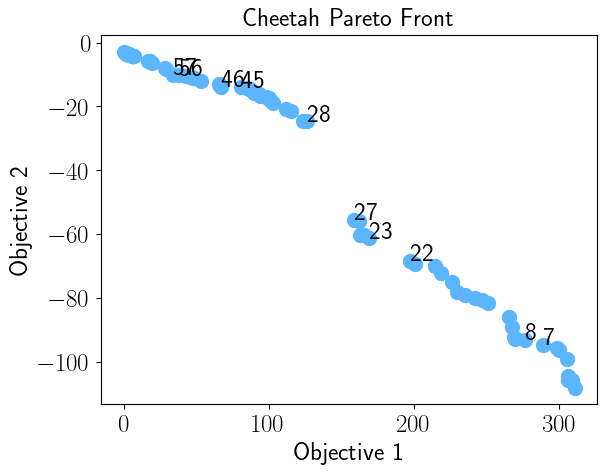

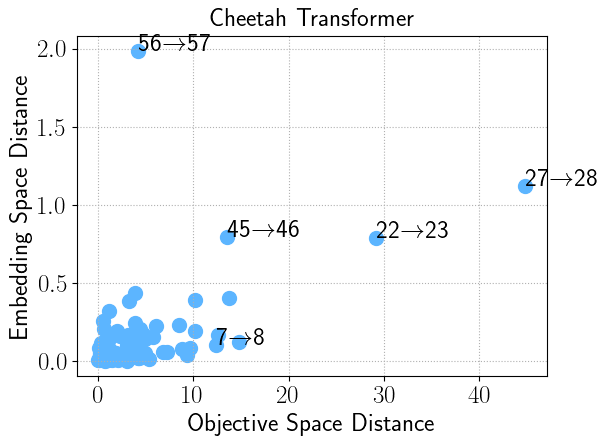

In [49]:
plt.scatter(sorted_pf_cheetah[:, 0], sorted_pf_cheetah[:, 1], c=colors[0], s=100)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
for i, txt in enumerate(range(len(sorted_pf_cheetah))):
    if i in {45, 46 , 7, 8, 27, 28, 22, 23, 56, 57}:
        plt.annotate(f"{i}", (sorted_pf_cheetah[i, 0], sorted_pf_cheetah[i, 1]))
plt.title("Cheetah Pareto Front")
plt.savefig(f"pareto_fronts/cheetah_{seed}.pdf")
plt.show()

# # plot cheetah embeddings in 3d
# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")
# ax.scatter(sorted_emb_cheetah[:, 0], sorted_emb_cheetah[:, 1], sorted_emb_cheetah[:, 2], c=colors[0], s=100)
# for i, txt in enumerate(range(len(sorted_emb_cheetah))):
#     ax.text(sorted_emb_cheetah[i, 0], sorted_emb_cheetah[i, 1], sorted_emb_cheetah[i, 2], f"{i}", fontsize=16, color="k")
# ax.set_xlabel("Embedding Dim 1")
# ax.set_ylabel("Embedding Dim 2")
# ax.set_zlabel("Embedding Dim 3")
# plt.title("Cheetah Embeddings")
# plt.tight_layout()
# plt.show()

# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
plt.scatter(d_objs_cheetah, d_embs_cheetah, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Cheetah Transformer")

# add index as text labels
for i, txt in enumerate(range(len(d_objs_cheetah))):
    if i in {45, 7, 27, 22, 56}:
        plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_cheetah[i], d_embs_cheetah[i]))

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig(f"scatterplots/cheetah_{seed}.pdf")
plt.show()

## Cheetah analysis

In [ ]:
# get policies with the highest lipshitz jump
sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
print(highest_pairs)
org_policy_id = np.lexsort(returns_cheetah.T)[highest_pairs[-1]]
render_policy(
    env_id="mo-halfcheetah-v5",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/highest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v5",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/highest",
    base_path="../..",
)

In [ ]:
# Get policies with the  secondhighest Lipschitz constants
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_cheetah.T)[highest_pairs[-2]]
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/second_highest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/second_highest",
    base_path="../..",
)

In [ ]:
# lowest
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[:]]
highest_pairs[0]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_cheetah.T)[highest_pairs[0]]
print(highest_pairs)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/lowest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/lowest",
    base_path="../..",
)

In [ ]:
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[:]]
highest_pairs[0]

## Analysis Hopper


In [ ]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
plt.scatter(d_objs_hopper_2d, d_embs_hopper_2d, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Hopper 2D Transformer")

# add pair labels
for i, txt in enumerate(range(len(d_objs_hopper_2d))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_hopper_2d[i], d_embs_hopper_2d[i]))

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

# plot hopper embeddings in 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_emb_hopper_2d[:, 0], sorted_emb_hopper_2d[:, 1], sorted_emb_hopper_2d[:, 2], c=colors[0], s=100)
for i, txt in enumerate(range(len(sorted_emb_hopper_2d))):
    ax.text(
        sorted_emb_hopper_2d[i, 0], sorted_emb_hopper_2d[i, 1], sorted_emb_hopper_2d[i, 2], f"{i}", fontsize=16, color="k"
    )
ax.set_xlabel("Embedding Dim 1")
ax.set_ylabel("Embedding Dim 2")
ax.set_zlabel("Embedding Dim 3")
plt.title("Hopper 2D Embeddings")
plt.tight_layout()
plt.show()

# plot hopper pf
plt.scatter(sorted_pf_hopper_2d[:, 0], sorted_pf_hopper_2d[:, 1], c=colors[0], s=100)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
for i, txt in enumerate(range(len(sorted_pf_hopper_2d))):
    plt.annotate(f"{i}", (sorted_pf_hopper_2d[i, 0], sorted_pf_hopper_2d[i, 1]))
plt.title("Hopper 2D Pareto Front")

plt.show()

# plot hopper embeddings in 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_emb_hopper_3d[:, 0], sorted_emb_hopper_3d[:, 1], sorted_emb_hopper_3d[:, 2], c=colors[0], s=100)
for i, txt in enumerate(range(len(sorted_emb_hopper_3d))):
    ax.text(
        sorted_emb_hopper_3d[i, 0], sorted_emb_hopper_3d[i, 1], sorted_emb_hopper_3d[i, 2], f"{i}", fontsize=16, color="k"
    )
ax.set_xlabel("Embedding Dim 1")
ax.set_ylabel("Embedding Dim 2")
ax.set_zlabel("Embedding Dim 3")
plt.title("Hopper 3D Embeddings")
plt.tight_layout()
plt.show()

# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
# TODO remove the point at index 139 -- CLEAN THIS UP
d_objs_hopper_3d = np.delete(d_objs_hopper_3d, 139)
d_embs_hopper_3d = np.delete(d_embs_hopper_3d, 139)

plt.scatter(d_objs_hopper_3d, d_embs_hopper_3d, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Hopper 3D Transformer")


# add pair labels
for i, txt in enumerate(range(len(d_objs_hopper_3d))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_hopper_3d[i], d_embs_hopper_3d[i]))
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

In [ ]:
# Hopper 3D Pareto Front 3D  scatter plot
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_pf_hopper_3d[:, 0], sorted_pf_hopper_3d[:, 1], sorted_pf_hopper_3d[:, 2], c=colors[0], s=100)
ax.set_xlabel("Objective 1")
ax.set_ylabel("Objective 2")
ax.set_zlabel("Objective 3")
plt.title("Hopper 3D Pareto Front")
for i, txt in enumerate(range(len(sorted_pf_hopper_3d))):
    if i in {72, 73}:
        ax.text(
            sorted_pf_hopper_3d[i, 0], sorted_pf_hopper_3d[i, 1], sorted_pf_hopper_3d[i, 2], f"{i}", fontsize=16, color="k"
        )
plt.show()

## Highway analysis

In [ ]:
# Get policies with the highest Lipschitz constants

sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_highway.T)[highest_pairs[-1]]
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/highway/highest",
    base_path="../..",
)
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/highway/highest",
    base_path="../..",
)

In [ ]:
# Get policies with the highest Lipschitz constants

sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_highway.T)[highest_pairs[-2]]
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/highway/second_highest",
    base_path="../..",
)
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/highway/second_highest",
    base_path="../..",
)

(40,)
(40,)


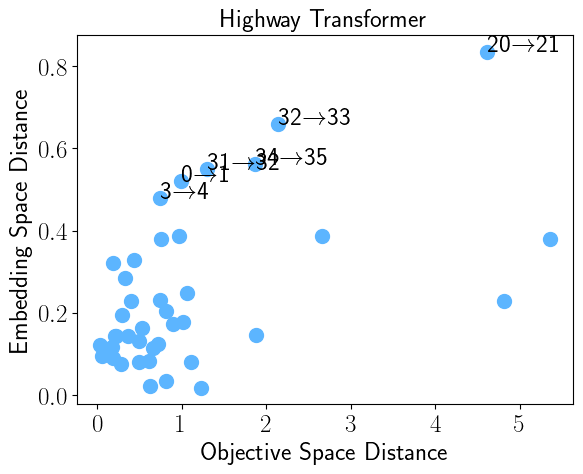

In [65]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
print(d_objs_highway.shape)
print(d_embs_highway.shape)
plt.scatter(d_objs_highway, d_embs_highway, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Highway Transformer")
# add index as text labels
for i, txt in enumerate(range(len(d_objs_highway))):
    if i in {0, 31, 20, 3, 34, 31, 32}:
        plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_highway[i], d_embs_highway[i]))

plt.show()

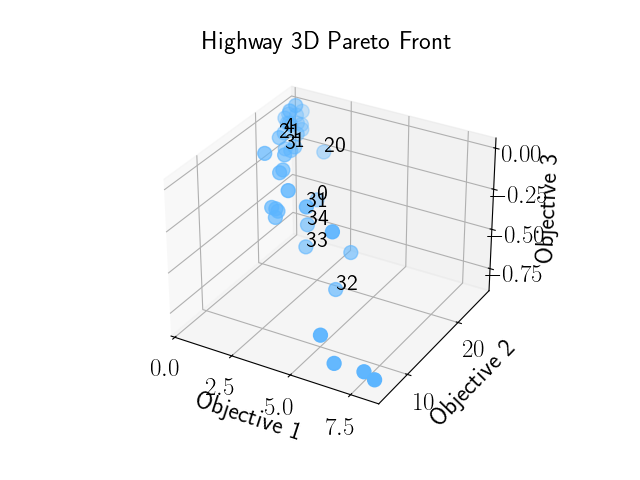

In [66]:
# Highway Pareto Front 3D  scatter plot
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_pf_highway[:, 0], sorted_pf_highway[:, 1], sorted_pf_highway[:, 2], c=colors[0], s=100)
ax.set_xlabel("Objective 1")
ax.set_ylabel("Objective 2")
ax.set_zlabel("Objective 3")
plt.title("Highway 3D Pareto Front")
for i, txt in enumerate(range(len(sorted_pf_highway))):
    if i in {0, 1, 31, 32, 33, 20, 21, 3, 4, 34}:
        ax.text(sorted_pf_highway[i, 0], sorted_pf_highway[i, 1], sorted_pf_highway[i, 2], f"{i}", fontsize=16, color="k")
plt.show()